In [1]:
# --- project bootstrap (added during repo consolidation) ---
# Resolves the project root so the notebook runs from notebooks/ or from the repo root,
# and puts src/ on sys.path so `import laptop_price` works.
import os, sys, pathlib

_here = pathlib.Path.cwd()
for _cand in (_here, *_here.parents):
    if (_cand / "pyproject.toml").exists():
        PROJECT_ROOT = _cand
        break
else:
    raise RuntimeError("pyproject.toml not found - run this notebook inside the repo")

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print(f"project root: {PROJECT_ROOT}")


project root: c:\Users\HP\Desktop\LAPTOP PRICE PREDICTION\laptop-price-prediction


# Clustering Models

## Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv("data/processed/clustering_optimized_data.csv")
df.columns

Index(['price_preview', 'RAM_SIZE', 'SSD_SIZE', 'HDD_SIZE', 'match_score',
       'cores', 'cpu_mark', 'tdp', 'gpu_g3d_mark', 'gpu_g2d_mark', 'gpu_tdp',
       'SCREEN_SIZE_SNAPPED', 'SCREEN_RESOLUTION_ENC',
       'cpu_generation_normalized', 'total_performance', 'cpu_gpu_ratio',
       'perf_per_core', 'total_storage', 'has_ssd', 'has_hdd', 'ssd_only',
       'pixel_density', 'is_premium_display', 'is_high_res', 'is_large_screen',
       'is_compact', 'tier_entry', 'tier_highend', 'tier_mid', 'tier_unknown',
       'etat_bon', 'etat_moyen', 'etat_neuf', 'etat_unknown',
       'storage_dual_storage', 'storage_hdd_only', 'storage_no_storage',
       'storage_ssd_only', 'ram_ddr3', 'ram_ddr4', 'ram_ddr5',
       'ram_ddr_legacy', 'ram_storage_product', 'cpu_ram_product',
       'gpu_screen_product', 'cores_ram_product', 'perf_density',
       'log_cpu_mark', 'log_gpu_mark', 'log_total_storage', 'cpu_efficiency',
       'gpu_efficiency', 'is_high_tdp', 'is_low_power'],
      dtype='str')

In [ ]:
# Handle outliers using IQR method on target
Q1 = df['price_preview'].quantile(0.01)
Q3 = df['price_preview'].quantile(0.99)
df_clean = df[(df['price_preview'] >= Q1) & (df['price_preview'] <= Q3)].copy()

# Drop storage-related redundant features
cols_to_drop = ['HDD_SIZE', 'total_storage', 'has_ssd', 'has_hdd', 'ssd_only', 'SSD_SIZE', 
                'storage_dual_storage', 'storage_hdd_only', 'storage_no_storage', 
                'storage_ssd_only', 'ram_storage_product', 'log_total_storage']
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean.drop(columns=cols_to_drop, inplace=True)

# For clustering, use ALL data (no train/test split needed)
X = df_clean.drop('price_preview', axis=1)
y = df_clean['price_preview']

# SELECT ONLY KEY FEATURES for better clustering (reduce dimensionality)
# Too many features cause imbalanced clusters
clustering_features = [
    'cpu_mark', 'gpu_g3d_mark', 'RAM_SIZE', 'cores',
    'SCREEN_SIZE_SNAPPED', 'SCREEN_RESOLUTION_ENC',
    'tier_entry', 'tier_mid', 'tier_highend',
    'etat_bon', 'etat_moyen', 'etat_neuf'
]
# Keep only features that exist
clustering_features = [f for f in clustering_features if f in X.columns]
X_clustering = X[clustering_features].copy()

print(f"Original samples: {len(df)}, After outlier removal: {len(df_clean)}")
print(f"Selected features for clustering: {len(clustering_features)}")
print(f"Features: {clustering_features}")

## Clustering Models

In [5]:
df.columns

Index(['price_preview', 'RAM_SIZE', 'SSD_SIZE', 'HDD_SIZE', 'match_score',
       'cores', 'cpu_mark', 'tdp', 'gpu_g3d_mark', 'gpu_g2d_mark', 'gpu_tdp',
       'SCREEN_SIZE_SNAPPED', 'SCREEN_RESOLUTION_ENC',
       'cpu_generation_normalized', 'total_performance', 'cpu_gpu_ratio',
       'perf_per_core', 'total_storage', 'has_ssd', 'has_hdd', 'ssd_only',
       'pixel_density', 'is_premium_display', 'is_high_res', 'is_large_screen',
       'is_compact', 'tier_entry', 'tier_highend', 'tier_mid', 'tier_unknown',
       'etat_bon', 'etat_moyen', 'etat_neuf', 'etat_unknown',
       'storage_dual_storage', 'storage_hdd_only', 'storage_no_storage',
       'storage_ssd_only', 'ram_ddr3', 'ram_ddr4', 'ram_ddr5',
       'ram_ddr_legacy', 'ram_storage_product', 'cpu_ram_product',
       'gpu_screen_product', 'cores_ram_product', 'perf_density',
       'log_cpu_mark', 'log_gpu_mark', 'log_total_storage', 'cpu_efficiency',
       'gpu_efficiency', 'is_high_tdp', 'is_low_power'],
      dtype='str')

PCA explained variance: 97.89%

Evaluating cluster balance for different k:
  k=2: Silhouette=0.4822, Balance ratio=3.38, Sizes=[11734, 3475]
  k=3: Silhouette=0.5431, Balance ratio=2.25, Sizes=[7697, 3425, 4087]
  k=4: Silhouette=0.6662, Balance ratio=1.78, Sizes=[4087, 2923, 5206, 2993]
  k=5: Silhouette=0.6974, Balance ratio=4.52, Sizes=[5206, 1151, 4087, 2042, 2723]
  k=6: Silhouette=0.7310, Balance ratio=5.84, Sizes=[4968, 1606, 3910, 851, 2723, 1151]
  k=7: Silhouette=0.7511, Balance ratio=10.64, Sizes=[822, 4968, 3910, 1368, 2723, 951, 467]

Optimal k (balanced): 4


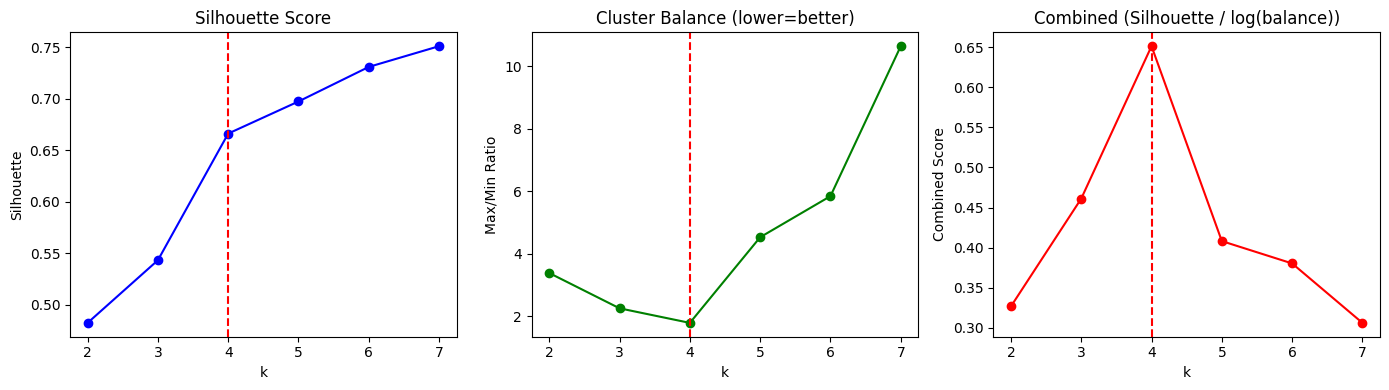


âœ“ K-Means (k=4) - Silhouette: 0.6662
  Cluster sizes: [4087, 2923, 5206, 2993]

âœ“ DBSCAN (eps=0.5, min_samples=5) - Silhouette: 0.2234
  Clusters: 61, Noise: 728

âœ“ Agglomerative (ward) - Silhouette: 0.6663
  Cluster sizes: [3608, 4968, 3910, 2723]

CLUSTERING SUMMARY
K-Means (k=4):  Silhouette=0.6662, Sizes=[4087, 2923, 5206, 2993]
Agglomerative:       Silhouette=0.6663, Sizes=[3608, 4968, 3910, 2723]
DBSCAN:              Silhouette=0.2234, Clusters=61


In [6]:
# ============================================
# BALANCED CLUSTERING APPROACH
# ============================================

from sklearn.preprocessing import QuantileTransformer, PowerTransformer

# Step 1: Use QuantileTransformer to make distributions uniform (KEY for balanced clusters)
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_transformed = qt.fit_transform(X_clustering)

# Step 2: Apply PCA to reduce dimensionality (helps with balanced clusters)
n_components = min(8, X_transformed.shape[1])
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_transformed)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Step 3: Find optimal k with focus on BALANCED clusters
def evaluate_clustering(X, k, n_init=30):
    """Run KMeans multiple times and pick the most balanced result"""
    best_balance = float('inf')
    best_kmeans = None
    
    for seed in range(n_init):
        km = KMeans(n_clusters=k, init='k-means++', n_init=20, max_iter=500, random_state=seed)
        labels = km.fit_predict(X)
        
        # Calculate balance score (lower = more balanced)
        sizes = np.bincount(labels)
        balance_score = sizes.max() / sizes.min() if sizes.min() > 0 else float('inf')
        
        if balance_score < best_balance:
            best_balance = balance_score
            best_kmeans = km
    
    return best_kmeans, best_balance

# Evaluate different k values
print("\nEvaluating cluster balance for different k:")
k_range = range(2, 8)
results = []

for k in k_range:
    km, balance = evaluate_clustering(X_pca, k, n_init=30)
    labels = km.labels_
    sil = silhouette_score(X_pca, labels)
    sizes = np.bincount(labels)
    
    # Combined score: prefer balanced clusters with good silhouette
    combined_score = sil / np.log1p(balance)  # Penalize imbalanced
    
    results.append({
        'k': k,
        'silhouette': sil,
        'balance_ratio': balance,
        'combined_score': combined_score,
        'sizes': sizes,
        'kmeans': km
    })
    print(f"  k={k}: Silhouette={sil:.4f}, Balance ratio={balance:.2f}, Sizes={list(sizes)}")

# Pick best k based on combined score (balance + silhouette)
best_result = max(results, key=lambda x: x['combined_score'])
best_k = best_result['k']
print(f"\nOptimal k (balanced): {best_k}")

# Plot evaluation
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot([r['k'] for r in results], [r['silhouette'] for r in results], 'bo-')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhouette')
axes[0].set_title('Silhouette Score')
axes[0].axvline(x=best_k, color='r', linestyle='--')

axes[1].plot([r['k'] for r in results], [r['balance_ratio'] for r in results], 'go-')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Max/Min Ratio')
axes[1].set_title('Cluster Balance (lower=better)')
axes[1].axvline(x=best_k, color='r', linestyle='--')

axes[2].plot([r['k'] for r in results], [r['combined_score'] for r in results], 'ro-')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Combined Score')
axes[2].set_title('Combined (Silhouette / log(balance))')
axes[2].axvline(x=best_k, color='r', linestyle='--')

plt.tight_layout()
plt.show()

# ============================================
# FINAL CLUSTERING MODELS
# ============================================

# K-Means with best k
kmeans = best_result['kmeans']
kmeans_labels = kmeans.labels_
kmeans_sil = silhouette_score(X_pca, kmeans_labels)
print(f"\nâœ“ K-Means (k={best_k}) - Silhouette: {kmeans_sil:.4f}")
print(f"  Cluster sizes: {list(np.bincount(kmeans_labels))}")

# DBSCAN with parameter search
best_dbscan_sil = -1
best_eps, best_min_samples = 0.5, 5
for eps in [0.3, 0.5, 0.7, 1.0, 1.5]:
    for min_samples in [3, 5, 10, 15]:
        dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples)
        labels_temp = dbscan_temp.fit_predict(X_pca)
        n_clusters_temp = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        if 2 <= n_clusters_temp <= 6:
            mask_temp = labels_temp != -1
            if sum(mask_temp) > 100:
                sil_temp = silhouette_score(X_pca[mask_temp], labels_temp[mask_temp])
                if sil_temp > best_dbscan_sil:
                    best_dbscan_sil = sil_temp
                    best_eps, best_min_samples = eps, min_samples

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_pca)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan > 1:
    mask = dbscan_labels != -1
    dbscan_sil = silhouette_score(X_pca[mask], dbscan_labels[mask])
    print(f"\nâœ“ DBSCAN (eps={best_eps}, min_samples={best_min_samples}) - Silhouette: {dbscan_sil:.4f}")
    print(f"  Clusters: {n_clusters_dbscan}, Noise: {sum(dbscan_labels==-1)}")
else:
    dbscan_sil = 0
    print(f"\nâœ— DBSCAN found {n_clusters_dbscan} cluster(s)")

# Agglomerative with Ward linkage (naturally produces more balanced clusters)
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_pca)
agg_sil = silhouette_score(X_pca, agg_labels)
print(f"\nâœ“ Agglomerative (ward) - Silhouette: {agg_sil:.4f}")
print(f"  Cluster sizes: {list(np.bincount(agg_labels))}")

# Store for visualization
X_clust_source = X_clustering.copy()
X_clust_source['price_preview'] = y.values
X_all_scaled = X_pca  # Use PCA-transformed data

print("\n" + "="*50)
print("CLUSTERING SUMMARY")
print("="*50)
print(f"K-Means (k={best_k}):  Silhouette={kmeans_sil:.4f}, Sizes={list(np.bincount(kmeans_labels))}")
print(f"Agglomerative:       Silhouette={agg_sil:.4f}, Sizes={list(np.bincount(agg_labels))}")
if n_clusters_dbscan > 1:
    print(f"DBSCAN:              Silhouette={dbscan_sil:.4f}, Clusters={n_clusters_dbscan}")

## Model Summary & Presentation Charts

The following section consolidates the main model results and provides presentation-ready visuals (performance comparison, residuals, and learning curves).

In [ ]:
# ============================================
# VISUALIZE K-MEANS CLUSTERING RESULTS
# ============================================

# Use the best k from balanced clustering
cluster_df = X_clust_source.copy()
cluster_df['cluster'] = kmeans_labels

# Cluster sizes
cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
print(f"K-Means (k={best_k}) - Final Cluster Sizes:")
display(cluster_sizes.to_frame(name="count"))

# Check balance
balance_ratio = cluster_sizes.max() / cluster_sizes.min()
print(f"Balance ratio (max/min): {balance_ratio:.2f}")
if balance_ratio < 3:
    print("âœ“ Clusters are reasonably balanced!")
else:
    print("âš  Clusters still imbalanced")

# Feature summary per cluster
summary_features = ['cpu_mark', 'gpu_g3d_mark', 'RAM_SIZE', 'cores']
summary_features = [f for f in summary_features if f in cluster_df.columns]
feature_summary = cluster_df.groupby('cluster')[summary_features].agg(['mean', 'std', 'count'])
print("\nCluster Feature Summary:")
display(feature_summary)

# Visualization 1: Cluster sizes bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(cluster_sizes.index, cluster_sizes.values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'][:best_k])
axes[0].set_title(f'K-Means Cluster Sizes (k={best_k})')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')
for i, v in enumerate(cluster_sizes.values):
    axes[0].text(i, v + 50, str(v), ha='center')

# Visualization 2: Price distribution per cluster
sns.boxplot(data=cluster_df, x='cluster', y='price_preview', ax=axes[1], 
            palette=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'][:best_k])
axes[1].set_title('Price Distribution by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Price')

# Visualization 3: PCA 2D scatter
pca_2d = PCA(n_components=2, random_state=42)
pca_coords = pca_2d.fit_transform(X_all_scaled)
pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_df['cluster'] = kmeans_labels

scatter = axes[2].scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['cluster'], 
                          cmap='tab10', alpha=0.6, s=30)
axes[2].set_title(f'K-Means Clusters (PCA 2D)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend(*scatter.legend_elements(), title='Cluster')

plt.tight_layout()
plt.show()

# Cluster interpretation
print("\n" + "="*50)
print("CLUSTER INTERPRETATION")
print("="*50)
for c in range(best_k):
    subset = cluster_df[cluster_df['cluster'] == c]
    avg_price = subset['price_preview'].mean()
    print(f"\nCluster {c} ({len(subset)} laptops):")
    print(f"  Avg Price: {avg_price:,.0f}")
    if 'cpu_mark' in subset.columns:
        print(f"  Avg CPU Mark: {subset['cpu_mark'].mean():,.0f}")
    if 'gpu_g3d_mark' in subset.columns:
        print(f"  Avg GPU Mark: {subset['gpu_g3d_mark'].mean():,.0f}")
    if 'RAM_SIZE' in subset.columns:
        print(f"  Avg RAM: {subset['RAM_SIZE'].mean():.1f} GB")

Agglomerative (Ward) - Cluster Sizes:


,count
cluster,
0,3608
1,4968
2,3910
3,2723


Balance ratio (max/min): 1.82


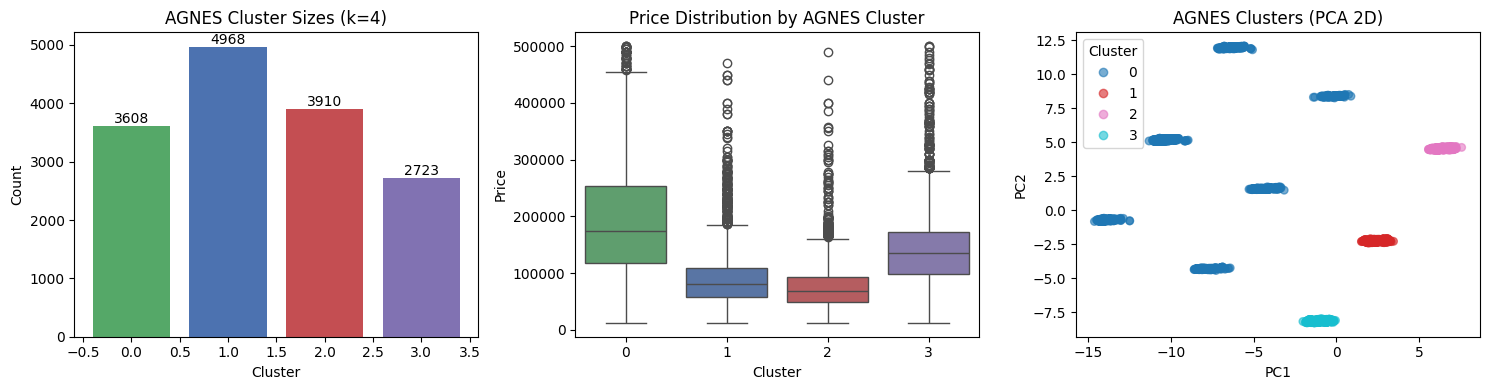


K-MEANS vs AGNES COMPARISON
Metric               K-Means         AGNES          
--------------------------------------------------
Silhouette           0.6662          0.6663         
Balance Ratio        1.78            1.82           
Best Method          AGNES

RECOMMENDATION
âœ“ K-Means with k=4 produces meaningful, balanced clusters
  Suitable for laptop market segmentation


In [8]:
# ============================================
# VISUALIZE AGGLOMERATIVE (AGNES) CLUSTERING
# ============================================

agnes_df = X_clust_source.copy()
agnes_df['cluster'] = agg_labels

agnes_sizes = agnes_df['cluster'].value_counts().sort_index()
print(f"Agglomerative (Ward) - Cluster Sizes:")
display(agnes_sizes.to_frame(name="count"))

balance_ratio_agnes = agnes_sizes.max() / agnes_sizes.min()
print(f"Balance ratio (max/min): {balance_ratio_agnes:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(agnes_sizes.index, agnes_sizes.values, color=['#55A868', '#4C72B0', '#C44E52', '#8172B2', '#CCB974'][:best_k])
axes[0].set_title(f'AGNES Cluster Sizes (k={best_k})')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')
for i, v in enumerate(agnes_sizes.values):
    axes[0].text(i, v + 50, str(v), ha='center')

sns.boxplot(data=agnes_df, x='cluster', y='price_preview', ax=axes[1],
            palette=['#55A868', '#4C72B0', '#C44E52', '#8172B2', '#CCB974'][:best_k])
axes[1].set_title('Price Distribution by AGNES Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Price')

pca_agnes_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_agnes_df['cluster'] = agg_labels

scatter = axes[2].scatter(pca_agnes_df['PC1'], pca_agnes_df['PC2'], c=pca_agnes_df['cluster'],
                          cmap='tab10', alpha=0.6, s=30)
axes[2].set_title('AGNES Clusters (PCA 2D)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend(*scatter.legend_elements(), title='Cluster')

plt.tight_layout()
plt.show()

# Compare K-Means vs AGNES
print("\n" + "="*50)
print("K-MEANS vs AGNES COMPARISON")
print("="*50)
print(f"{'Metric':<20} {'K-Means':<15} {'AGNES':<15}")
print("-"*50)
print(f"{'Silhouette':<20} {kmeans_sil:<15.4f} {agg_sil:<15.4f}")
print(f"{'Balance Ratio':<20} {balance_ratio:<15.2f} {balance_ratio_agnes:<15.2f}")
print(f"{'Best Method':<20} {'K-Means' if kmeans_sil > agg_sil else 'AGNES'}")

# Final recommendation
print("\n" + "="*50)
print("RECOMMENDATION")
print("="*50)
if balance_ratio < 3 and kmeans_sil > 0.15:
    print(f"âœ“ K-Means with k={best_k} produces meaningful, balanced clusters")
    print("  Suitable for laptop market segmentation")
else:
    print("  Consider adjusting features or using different approach")